# 🚉 Buenos Aires Subway

## Part 1: Data structures

As a data analyst, we are examining public transportation accessibility in Buenos Aires, Argentina, for an upcoming project. We are particularly interested in the subway system as an efficient way to navigate the city. We will first focus on the Pueyrredon station on Line D of the subway and examine its ridership.


<div style="text-align: center;">
    <img src="images/subway_map_wcircle.jpg" alt="Subway map" width="1000"/>
</div>

<div style="text-align: center;">
    <a href="https://emova.com.ar/wp-content/uploads/2023/09/Mapa_Emova_2023-color-.jpg">image source</a>
</div>


### Table of Contents

- [Step 1: Load the data](#step-1)
- [Step 2: Migrating from lists to a DataFrame](#step-2)
- [Step 3: Select columns](#step-3)
- [Step 4: Calculate the sum per column](#step-4)


<a id="step-1"></a>
### Step 1: Load the data

First, we will import `pandas` and load the dataset as a pandas DataFrame. The CSV will have these features:

* `datetime` - hour and date the measurement was taken
* `line` - subway line
* `station`	- station name
* `pax_pagos` - paying passengers
* `pax_pases_pagos` - passengers who paid with passes
* `pax_franq` - passengers who paid with deductibles
* `pax_total` - total number of passengers who used the turnstile


In [2]:
# Import pandas
import pandas as pd

# Load the CSV to a DataFrame
df = pd.read_csv("pueyrredon_march2024_8-11.csv")

# Preview the first 5 rows
df.head()

,datetime,station,line,pax_pagos,pax_pases_pagos,pax_franq,pax_TOTAL
0,2024-03-01 08:00:00,Pueyrredon.D,D,0,0,6,6
1,2024-03-01 09:00:00,Pueyrredon.D,D,0,0,5,5
2,2024-03-01 10:00:00,Pueyrredon.D,D,0,0,2,2
3,2024-03-01 11:00:00,Pueyrredon.D,D,0,0,3,3
4,2024-03-02 08:00:00,Pueyrredon.D,D,0,0,1,1


In [3]:
# Check 10 random samples
df.sample(10)

,datetime,station,line,pax_pagos,pax_pases_pagos,pax_franq,pax_TOTAL
71,2024-03-20 11:00:00,Pueyrredon.D,D,176,0,12,188
27,2024-03-09 11:00:00,Pueyrredon.D,D,217,0,8,225
79,2024-03-22 11:00:00,Pueyrredon.D,D,444,0,45,489
5,2024-03-04 08:00:00,Pueyrredon.D,D,0,0,1,1
3,2024-03-01 11:00:00,Pueyrredon.D,D,0,0,3,3
85,2024-03-24 09:00:00,Pueyrredon.D,D,47,0,0,47
32,2024-03-11 08:00:00,Pueyrredon.D,D,408,2,15,425
15,2024-03-06 11:00:00,Pueyrredon.D,D,0,0,5,5
83,2024-03-23 11:00:00,Pueyrredon.D,D,212,0,4,216
13,2024-03-06 09:00:00,Pueyrredon.D,D,0,0,6,6


<a id="step-2"></a>
### Step 2: Inspect the dataset

* Next, we will inspect **characteristics** of the DataFrame to understand the data.

In [4]:
# Get the columns
df_columns = df.columns

# Get the datatypes
df_dtypes = df.dtypes

print("The columns of the dataset are:", list(df_columns))
print("\nThe data types of each column are:\n")
print(df_dtypes)

The columns of the dataset are: ['datetime', 'station', 'line', 'pax_pagos', 'pax_pases_pagos', 'pax_franq', 'pax_TOTAL']

The data types of each column are:

datetime           object
station            object
line               object
pax_pagos           int64
pax_pases_pagos     int64
pax_franq           int64
pax_TOTAL           int64
dtype: object


* Another way to extract these information is to use the `.info()` method. This also provides a `Non-Null Count` column that detects if there are any null values in the dataset.

In [5]:
# Print a summary of the features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   datetime         116 non-null    object
 1   station          116 non-null    object
 2   line             116 non-null    object
 3   pax_pagos        116 non-null    int64 
 4   pax_pases_pagos  116 non-null    int64 
 5   pax_franq        116 non-null    int64 
 6   pax_TOTAL        116 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 6.5+ KB


<a id="step-3"></a>
### Step 3: Select columns

In real world data, we might receive a lot of features that we don't really need in our analysis. We might be interested in only a handful of features. We can select these specific columns in DataFrames to simplify our dataset. For example, in this use case, we don't find the `station` and `line` columns to be useful because they're the same for every row.


In [6]:
# Get the list of features without `station` and `line`
columns = ['datetime', 'pax_pagos', 'pax_pases_pagos', 'pax_franq', 'pax_TOTAL']

# Select the columns in the list above
df_pax = df[columns]

# Preview the simplified DataFrame
df_pax.head()

,datetime,pax_pagos,pax_pases_pagos,pax_franq,pax_TOTAL
0,2024-03-01 08:00:00,0,0,6,6
1,2024-03-01 09:00:00,0,0,5,5
2,2024-03-01 10:00:00,0,0,2,2
3,2024-03-01 11:00:00,0,0,3,3
4,2024-03-02 08:00:00,0,0,1,1


In [7]:
# Print a summary of the features
df_pax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   datetime         116 non-null    object
 1   pax_pagos        116 non-null    int64 
 2   pax_pases_pagos  116 non-null    int64 
 3   pax_franq        116 non-null    int64 
 4   pax_TOTAL        116 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 4.7+ KB


<a id="step-4"></a>
### Step 4: Calculate the sum per column

* We want to calculate **how much each type of passenger payment contributes to the total passenger count**. This can help us quantify how much discounted rates affects the total revenue for that particular month.

In [8]:
# Get the sum for `pax_pagos`
df_pax_pagos = df_pax["pax_pagos"].sum()

# Get the sum for `pax_pases_pagos`
df_pax_pases_pagos = df_pax["pax_pases_pagos"].sum()

# Get the sum for `pax_franq`
df_pax_franq = df_pax["pax_franq"].sum()

# Get the sum for `pax_TOTAL`
df_pax_total = df_pax["pax_TOTAL"].sum()

print("Percent of `pax_pagos`:", (df_pax_pagos/df_pax_total*100))
print("Percent of `pax_pases_pagos`:", (df_pax_pases_pagos/df_pax_total*100))
print("Percent of `pax_franq`:", (df_pax_franq/df_pax_total*100))

Percent of `pax_pagos`: 93.89642215324294
Percent of `pax_pases_pagos`: 0.04247671949027937
Percent of `pax_franq`: 6.061101127266786


* We can also get some preliminary visualization of the data. Say we want to visually inspect what is the typical total passenger count at these hours. We can use the `.hist()` method to do just that.

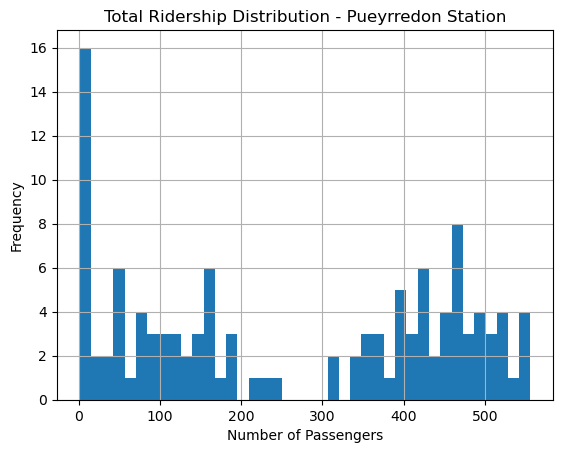

In [9]:
# Generate a histogram of `pax_TOTAL`
import matplotlib.pyplot as plt

df_pax["pax_TOTAL"].hist(bins=40)
plt.title("Total Ridership Distribution - Pueyrredon Station")
plt.xlabel("Number of Passengers")
plt.ylabel("Frequency")
plt.savefig('images/pax_distribution.png', bbox_inches='tight')

The histogram for the Pueyrredon station data provides a visual overview of how busy the station was during the month of March.

### Summary of the Histogram

* **Purpose:** It groups the number of passengers into ranges (called **bins**) to show the overall distribution of ridership rather than individual data points.
* **X-Axis (Horizontal):** Represents the **volume of passengers** per hour. The left side shows low numbers (quiet periods), and the right side shows high numbers (rush hour).
* **Y-Axis (Vertical):** Represents the **frequency**, or how many hours in the dataset fell into those specific passenger ranges.
* **The Findings:** The chart typically shows a **skewed distribution**. This means that most recorded hours had relatively low passenger counts (tall bars on the left), while the high-traffic peak moments were much less frequent (short bars on the right).

## Part 2: Sorting and filtering

We're continuing our exploration of the Buenos Aires Subway system and want to look at the busiest stations. We now have all passenger counts for all stations in the subway network, for all open hours for the month of March 2024. Our analysis can help us recommend if a station will need more train cars to accommodate the traffic or how much resources are needed for crowd control. 


### Table of Contents

- [Step 1: Load and sort the dataset](#step-1)
- [Step 2: Filter a subway line](#step-2)
- [Step 3: Select rows](#step-3)
- [Step 4: Filter rush hours](#step-4)

<a id="step-1"></a>
### Step 1: Load and sort the dataset

We are importing a new CSV file. This data corresponds to the number of passengers at every station in the subway system of Buenos Aires in March 2024, with an hourly granularity. It consists of 5 features:

- `date`: date of the observation, in format YYYY-MM-DD
- `hour`: hour of the observation
- `station`: name of the subway station
- `line`: name of the subway line (A, B, C, D, E, H). Each line corresponds to one of the colored lines in the map above.
- `pax_TOTAL`: total number of passengers at the station 

In [11]:
# Load the data
df2 = pd.read_csv("march2024_pax_hourly.csv")

# Show the first few rows
df2.head()

,date,hour,station,line,pax_TOTAL
0,2024-03-01,5,Acoyte,A,50
1,2024-03-01,5,Aguero,D,1
2,2024-03-01,5,Alberti,A,6
3,2024-03-01,5,Angel Gallardo,B,30
4,2024-03-01,5,Avenida La Plata,E,26


In [12]:
# Check a random sample
df2.sample(10)

,date,hour,station,line,pax_TOTAL
27874,2024-03-18,18,General San Martin,C,831
44768,2024-03-29,7,Tronador,B,7
19406,2024-03-13,15,Acoyte,A,544
10190,2024-03-07,22,Constitucion,C,345
43925,2024-03-28,14,Independencia.H,E,146
10783,2024-03-08,9,Urquiza,E,253
48314,2024-03-31,12,Pza. de los Virreyes,E,122
11114,2024-03-08,13,Pasteur,B,759
10126,2024-03-07,21,Lavalle,C,177
22082,2024-03-15,7,Emilio Mitre,E,561


In [13]:
import helper_functions

# Utility function for printing rows and stations
helper_functions.print_rows_stations(df2)

number of rows: 49219

stations in this DataFrame:
['Acoyte' 'Aguero' 'Alberti' 'Angel Gallardo' 'Avenida La Plata'
 'Avenida de Mayo' 'Boedo' 'Bolivar' 'Callao.B' 'Carabobo' 'Carlos Gardel'
 'Carlos Pellegrini' 'Caseros' 'Castro Barros' 'Catalinas' 'Congreso'
 'Constitucion' 'Cordoba' 'Correo Central' 'Corrientes' 'Diagonal Norte'
 'Dorrego' 'Echeverria' 'Emilio Mitre' 'Entre Rios' 'Facultad de Derecho'
 'Federico Lacroze' 'Flores' 'Florida' 'General Belgrano'
 'General San Martin' 'Hospitales' 'Humberto I' 'Inclan' 'Independencia'
 'Independencia.H' 'Jose Maria Moreno' 'Jujuy' 'Las Heras' 'Lavalle'
 'Leandro N. Alem' 'Lima' 'Loria' 'Los Incas' 'Malabia' 'Mariano Moreno'
 'Medalla Milagrosa' 'Medrano' 'Ministro Carranza' 'Once' 'Pasco'
 'Pasteur' 'Patricios' 'Peru' 'Pichincha' 'Piedras' 'Plaza Italia'
 'Plaza Miserere' 'Plaza de Mayo' 'Primera Junta' 'Puan' 'Pueyrredon'
 'Pza. de los Virreyes' 'Retiro' 'Retiro E' 'Rio de Janeiro' 'Rosas'
 'Saenz Pena ' 'San Jose' 'San Juan' 'San Pedri

* Now that we've seen some characteristics of the dataset, we want to sort it by `line` and `pax_TOTAL` so we can analyze the busiest times in each subway line.

In [14]:
# Create a list of strings to hold two features: 'line' and 'pax_TOTAL'
columns = ["line", "pax_TOTAL"]

# Create a list of booleans to specify the sorting order. 'line' is ascending, 'pax_TOTAL' is descending
order = [True, False]

# Sort the dataframe by the columns and order specified above
df_sorted = df2.sort_values(by=columns, ascending=order)

# Preview the results
df_sorted.head()

,date,hour,station,line,pax_TOTAL
40234,2024-03-26,8,San Pedrito,A,4252
32079,2024-03-21,8,San Pedrito,A,4179
28713,2024-03-19,8,San Pedrito,A,4169
41920,2024-03-27,8,San Pedrito,A,4099
38548,2024-03-25,8,San Pedrito,A,4081


<a id="step-2"></a>

### Step 2: Filter a subway line

Now that we have the sorted dataset, we can filter a subway line and it will return a sorted dataset by total passengers. Lets filter line E.

In [15]:
line = "E"

# Filter `df_sorted` for rows that match the line specified
df_filter_line = df_sorted[df_sorted["line"] == line]

# Check the types
print(type(df_filter_line), type(df_sorted["line"]))

# Print the station names for selected rows
helper_functions.print_rows_stations(df_filter_line)

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>
number of rows: 10135

stations in this DataFrame:
['Independencia.H' 'Bolivar' 'Pza. de los Virreyes' 'Catalinas'
 'Correo Central' 'General Belgrano' 'Avenida La Plata' 'Emilio Mitre'
 'Jose Maria Moreno' 'Retiro E' 'Boedo' 'Urquiza' 'San Jose' 'Entre Rios'
 'Varela' 'Medalla Milagrosa' 'Pichincha' 'Jujuy']



* If we look at the resulting DataFrame, every row should have the `line` column equals `E`.

In [16]:
# Preview the result
df_filter_line.head()

,date,hour,station,line,pax_TOTAL
15805,2024-03-11,12,Independencia.H,E,2371
29029,2024-03-19,12,Independencia.H,E,2283
27345,2024-03-18,12,Independencia.H,E,2226
29442,2024-03-19,17,Bolivar,E,2195
16218,2024-03-11,17,Bolivar,E,2192


<a id="step-3"></a>

### Step 3: Select top rows

* We only want the most crowded times so you need to reduce the dataset. We will be slicing the dataset to select a range of rows.


In [17]:
# Slice the first 500 rows
df_sliced = df_filter_line.iloc[0:500]

# Print the station names for selected rows
helper_functions.print_rows_stations(df_sliced)

number of rows: 500

stations in this DataFrame:
['Independencia.H' 'Bolivar' 'Pza. de los Virreyes' 'Catalinas'
 'Correo Central' 'General Belgrano' 'Avenida La Plata' 'Emilio Mitre'
 'Jose Maria Moreno' 'Retiro E' 'Boedo']



<a id="step-4"></a>

### Step 4: Filter rush hours

Now we have a subset of the data containing the top 500 data points by total number of passengers. If we want to know what times these usually occur, we can plot a histogram of the 'hour' feature and see which hours have the highest peaks.

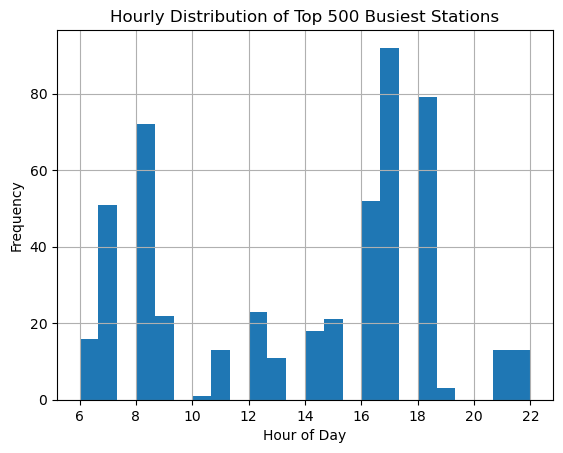

In [18]:
# Visualize when the busiest times occur
df_sliced["hour"].hist(bins=24)

plt.title("Hourly Distribution of Top 500 Busiest Stations")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")
plt.savefig('images/rush_hour_peaks.png', bbox_inches='tight')

This histogram analyzes the "Top 500" busiest records to pinpoint exactly when congestion occurs across the network.

### Summary of the Histogram

* **Purpose:** It identifies the specific times of day that consistently produce the highest passenger volumes.
* **X-Axis (Horizontal):** Represents the **hour of the day** (from 0 to 23). By using **24 bins**, each bar represents exactly one hour of a full day cycle.
* **Y-Axis (Vertical):** Represents the **frequency** of extreme events. It counts how many times a specific hour appeared in the list of the 500 most crowded records.
* **The Findings:** The chart typically reveals **Bimodal Peaks**. You will see two distinct tall bars or "humps"—one in the morning (around 8:00 AM) and one in the late afternoon (between 16:00 and 18:00). This confirms the standard commuter "Rush Hour" pattern.


* The chart show several peaks. Though, we want to focus on the afternoon rush hour between 16:00 to 18:00.

In [19]:
# Filter `df_sliced` for 'hour' greater than or equal to 16, and less than or equal to 18
df_filter_peak = df_sliced[(df_sliced["hour"]>=16) & (df_sliced["hour"]<=18)]

helper_functions.print_rows_stations(df_filter_peak)

number of rows: 223

stations in this DataFrame:
['Bolivar' 'Independencia.H' 'Catalinas' 'Correo Central'
 'General Belgrano' 'Retiro E']



* Now we see these **6 stations** are the **busiest on Line E** based on the criteria we specified. We can recommend these to our stakeholders as the ones needing the most attention during these hours.

## Part-3: Descriptive statistics


* Now we want to capture some descriptive statistics so we can further quantify how much resources are needed to manage the traffic.

### Table of Contents

- [Step 1: Load and filter the data](#step-1)
- [Step 2: Descriptive statistics](#step-2)
- [Step 3: Plot the station counts](#step-3)
- [Step 4: Statistics per station](#step-4)
- [Step 5: Statistics per hour and subway line](#step-5)

### Step 1: Load and filter the data
<a id="step-1-load-the-data"></a>
We begin by loading the data. It is the same one (df2) and has these features:

- `date`: date of the observation, in format YYYY-MM-DD
- `hour`: hour of the observation
- `station`: name of the subway station
- `line`: name of the subway line (A, B, C, D, E, H). Each line corresponds to one of the colored lines in the map above.
- `pax_TOTAL`: total number of passengers at the station 

In [20]:
# Preview the DataFrame
print(df2.head())

print("\nRows in the dataset:", len(df2))

         date  hour           station line  pax_TOTAL
0  2024-03-01     5            Acoyte    A         50
1  2024-03-01     5            Aguero    D          1
2  2024-03-01     5           Alberti    A          6
3  2024-03-01     5    Angel Gallardo    B         30
4  2024-03-01     5  Avenida La Plata    E         26

Rows in the dataset: 49219


* We want to calculate numbers for extreme conditions so we decide to filter the dataset.
* We use the `quantile()` method to get the 0.95 quantile of the `pax_TOTAL` and store it in the <code>pax_95q</code> variable.

In [21]:
# Get the 95th percentile of the total passengers
pax_95q = df2["pax_TOTAL"].quantile(0.95)
print("\n95th percentile of Total Passengers:", pax_95q)

# Filter the dataset
df_95q = df2[df2["pax_TOTAL"] > pax_95q]
print("\nFiltered dataset containing top 5% of total passengers:\n", df_95q)

# Sort the dataset
df_95q = df_95q.sort_values(by=["pax_TOTAL"], ascending=False)
print("\nDataset sorted in descending order of total passengers (containing top 5% of total passengers):\n", df_95q)

# Print the number of rows
print("rows in this dataset:",len(df_95q))


95th percentile of Total Passengers: 1184.0999999999985

Filtered dataset containing top 5% of total passengers:
              date  hour           station line  pax_TOTAL
16     2024-03-01     5      Constitucion    C       1592
94     2024-03-01     6      Constitucion    C       5659
173    2024-03-01     7      Constitucion    C       8041
183    2024-03-01     7  Federico Lacroze    B       1978
188    2024-03-01     7        Hospitales    H       1858
...           ...   ...               ...  ...        ...
47496  2024-03-30    20            Retiro    C       1251
48085  2024-03-31    10      Constitucion    C       1310
48174  2024-03-31    11      Constitucion    C       1257
48263  2024-03-31    12      Constitucion    C       1414
48708  2024-03-31    17      Constitucion    C       1347

[2461 rows x 5 columns]

Dataset sorted in descending order of total passengers (containing top 5% of total passengers):
              date  hour         station line  pax_TOTAL
40175  202

### Step 2: Calculating Descriptive statistics

Now we calculate some numbers to see how many passengers are in these busy conditions.

We find the **mean, median, standard deviation** and **maximum number** of total passengers in the <code>df_95q</code> DataFrame.

In [22]:
pax_mean = df_95q["pax_TOTAL"].mean()
pax_median = df_95q["pax_TOTAL"].median()
pax_max = df_95q["pax_TOTAL"].max()
pax_std = df_95q["pax_TOTAL"].std()

print("The mean pax is:", pax_mean)
print("The median pax is:", pax_median)
print("The max pax is:", pax_max)
print("The standard deviation is:", pax_std)

The mean pax is: 2034.19179195449
The median pax is: 1580.0
The max pax is: 13651
The standard deviation is: 1429.2539690049255


<a id="step-3"></a>

### Step 3: Plot the station counts

We want to know the top stations that encounter this kind of passenger traffic.

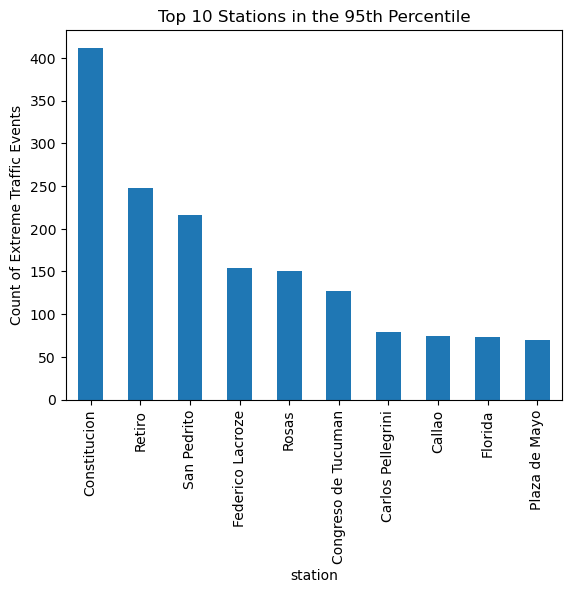

In [26]:
# Getting the value counts per station
station_counts = df_95q["station"].value_counts()

# Selecting the top 10 busiest stations
station_counts_10 = station_counts.head(10)

# Plotting the top 10 busiest stations
station_counts_10.plot(kind="bar")

plt.title("Top 10 Stations in the 95th Percentile")
plt.ylabel("Count of Extreme Traffic Events")
plt.savefig('images/top_stations_bar.png', bbox_inches='tight')

This chart (technically a bar chart used for distribution) identifies which stations are most prone to hitting their capacity limits.

### Summary of Histogram

* **Purpose:** It isolates the stations that most frequently exceed the **95th percentile ridership threshold**.
* **X-Axis (Horizontal):** Lists the **Subway Stations**. Usually, this is limited to the "Top 10" to keep the visual clear and actionable.
* **Y-Axis (Vertical):** Represents the **event count**. It shows how many times that specific station experienced a "95th percentile" traffic event during the month.
* **The Findings:** This chart highlights the **Critical Hubs**. Even if many stations are busy, a few specific stations (like Constitución) will have significantly taller bars. This tells stakeholders exactly where to prioritize physical infrastructure upgrades, such as wider platforms or additional turnstiles.


<a id="step-4"></a>

### Step 4: Statistics per station

* Next, we want to plot some statistics segmented per station. We will calculate the mean and return the results as a series. 

In [24]:
# Segment the data by station
df_grouped_station = df_95q.groupby("station")

# Calculate the mean of the 'pax_TOTAL' column per station
mean_per_station = df_grouped_station["pax_TOTAL"].mean()

# Sort the results and only print the top 10
mean_per_station.sort_values(ascending=False).head(10)

station
Constitucion        3603.701456
Catedral            2134.927536
Plaza de Mayo       2067.885714
Retiro              1991.120968
Rosas               1982.820000
San Pedrito         1926.078704
Saenz Pena          1910.250000
Hospitales          1892.000000
Leandro N. Alem     1888.698413
Federico Lacroze    1830.571429
Name: pax_TOTAL, dtype: float64

<a id="step-5"></a>

### Step 5: Statistics per hour and subway line

Lastly, we want to calculate statistics both by hour and line. This will allow us to see which times these conditions occurred on each line.


In [33]:
# Create the pivot table
pivot_hour_line = df_95q.pivot_table(index="hour",
                                     columns="line",
                                     values="pax_TOTAL",
                                     aggfunc="mean")
# Print the results
pivot_hour_line

line,A,B,C,D,E,H
hour,,,,,,
5,NaN,NaN,1738.736842,NaN,NaN,NaN
6,1281.285714,1296.307692,5499.083333,NaN,NaN,NaN
7,1866.111111,2807.432432,5617.159091,2317.266667,1423.500000,1918.875000
8,1863.699029,2611.433333,6060.869565,2534.125000,1397.312500,1740.250000
9,1675.229167,2120.978261,4246.312500,1864.000000,NaN,1315.363636
10,1391.352941,1378.290323,2690.500000,1362.750000,NaN,NaN
11,1432.294118,1312.250000,2639.864865,1309.375000,1835.000000,NaN
12,1573.407407,1324.875000,2192.367347,1536.666667,2023.538462,NaN
13,1710.458333,1350.277778,2507.519231,1436.304348,NaN,NaN


Now we see that some lines can have busy stations almost throughout the day. Some have an interesting pattern, like line E where it's usually below the threshold but encountered high passenger counts well into the night (hour 21 and 22).